#Integrantes
- Christopher Andres Obando Rivera
- Mateo Murcia Valles

Para este trabajo donde queremos aplicar los siguientes métodos de regresión:
1. Regresión Lineal

2. Regresión con Regularización

3. Random Forest

4. Máquinas de Soporte Vectorial

5. Redes Neuronales

Decidimos trabajar con la base de datos **California Housing** de scikit-learn.

**Explicación sobre la base de datos:**

Este conjunto de datos contiene información sobre diferentes zonas residenciales en California. Cada fila representa un "grupo de manzanas" (una zona geográfica pequeña) y nos ayuda a entender qué factores influyen en el precio de las casas.

**Variables que usamos para predecir:**
* **MedInc (Ingreso Medio):** Cuánto ganan en promedio las familias que viven en esa zona.
* **HouseAge (Edad de la Vivienda):** Qué tan antiguas son, en promedio, las casas de la zona.
* **AveRooms (Promedio de Habitaciones):** Cantidad media de cuartos por casa.
* **AveBedrms (Promedio de Dormitorios):** Cantidad media de habitaciones para dormir por casa.
* **Population (Población):** Cuántas personas viven en total en esa zona.
* **AveOccup (Ocupación Promedio):** Cuántas personas viven, en promedio, dentro de una misma casa.
* **Latitude (Latitud):** Qué tan al norte o al sur está ubicada la zona.
* **Longitude (Longitud):** Qué tan al este o al oeste está ubicada la zona.

**Variable que queremos predecir:**
* **MedHouseVal (Valor Medio de la Vivienda):** El precio promedio de las casas en esa zona (medido en cientos de miles de dólares).

# Carga y análisis exploratorio de la base de datos

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing

california = fetch_california_housing()

df = pd.DataFrame(california.data, columns=california.feature_names)

df['MedHouseVal'] = california.target

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


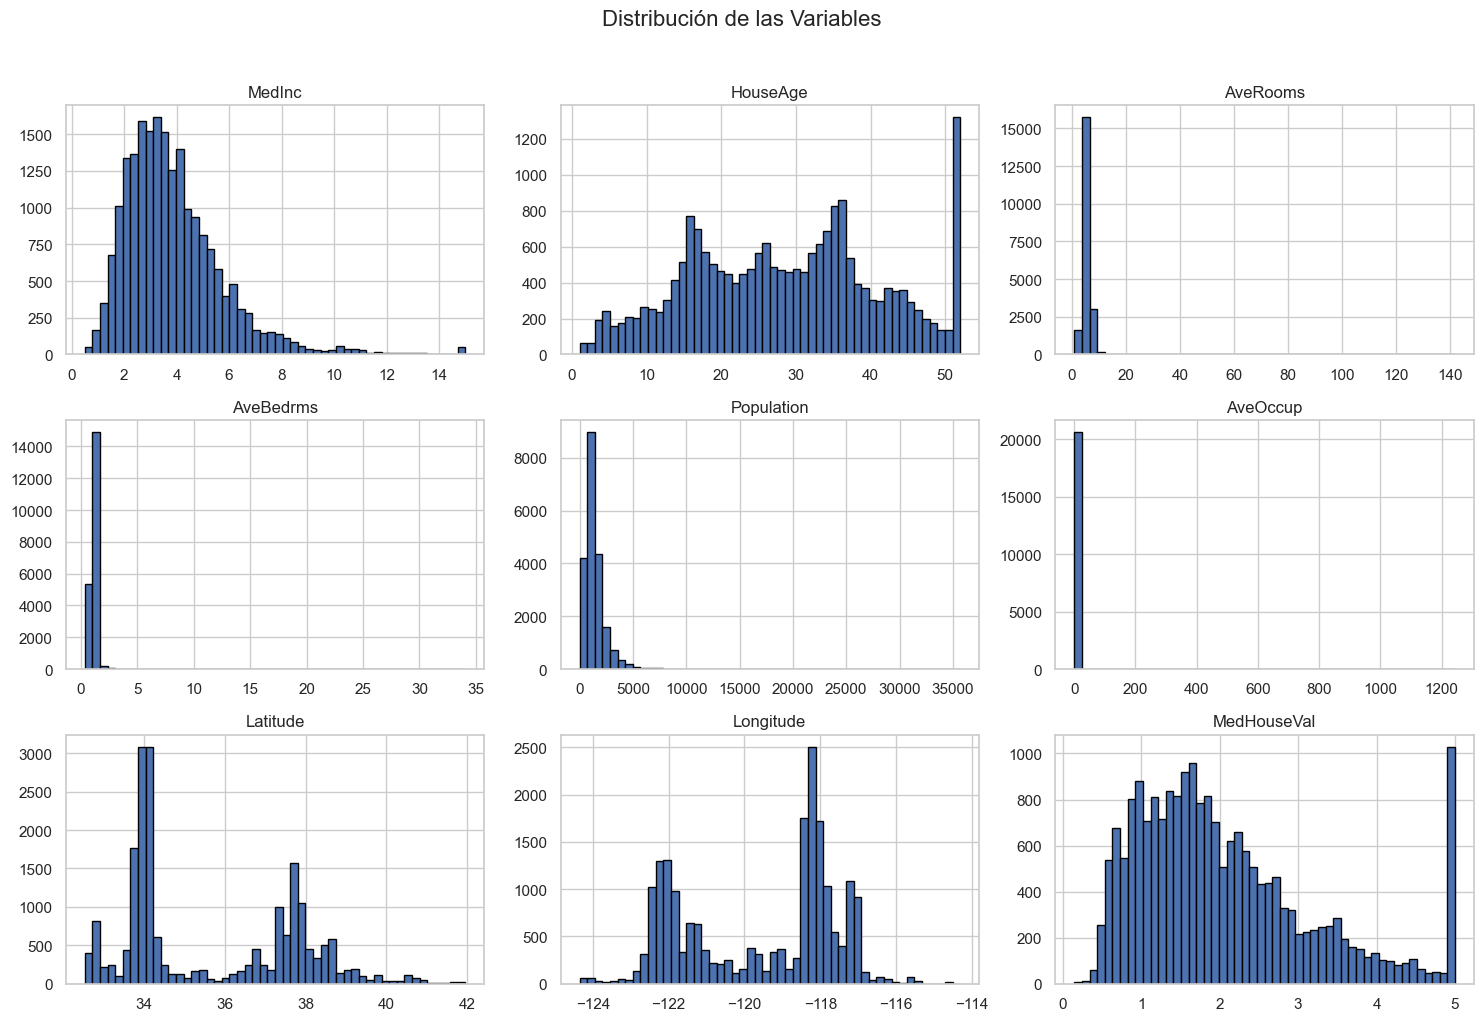

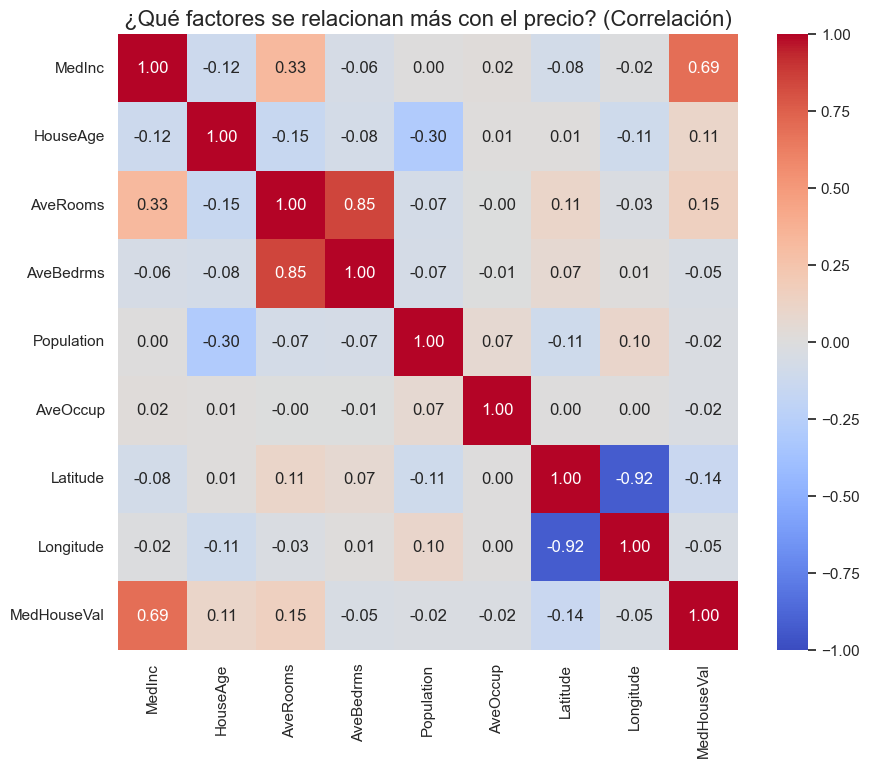

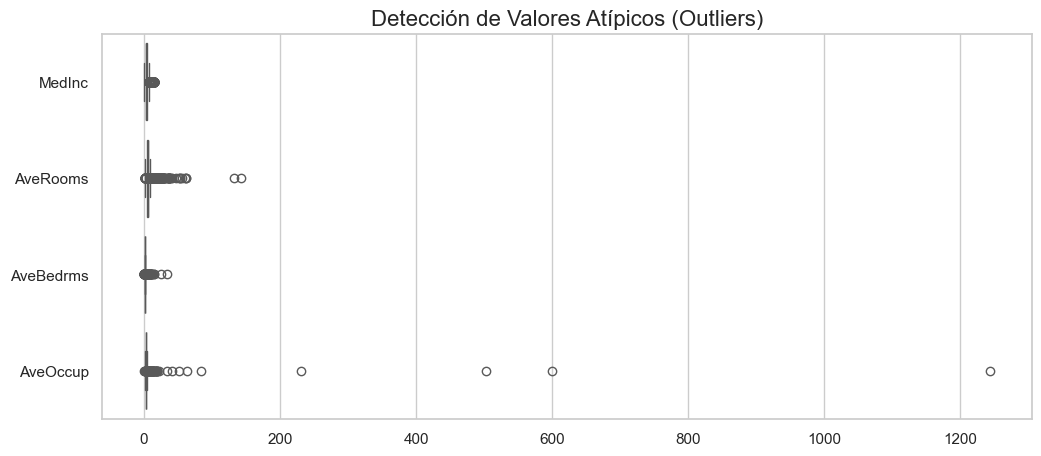

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

display(df.describe().round(2))

sns.set_theme(style="whitegrid")

# Distribuciones de las variables
df.hist(bins=50, figsize=(15, 10), color='#4C72B0', edgecolor='black')
plt.suptitle("Distribución de las Variables", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# Matriz de Correlación
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("¿Qué factores se relacionan más con el precio? (Correlación)", fontsize=16)
plt.show()

# Búsqueda de Valores Atípicos
plt.figure(figsize=(12, 5))
sns.boxplot(data=df[['MedInc', 'AveRooms', 'AveBedrms', 'AveOccup']], orient="h", palette="Set2")
plt.title("Detección de Valores Atípicos (Outliers)", fontsize=16)
plt.show()

Antes de crear modelos predictivos, exploramos nuestros datos para entender su comportamiento. Esto es lo que descubrimos:

### 1. ¿Qué afecta más el precio de la vivienda?
Al mirar nuestro mapa de calor (matriz de correlación), encontramos un factor dominante:
* **El Ingreso Medio (`MedInc`):** Hay una relación positiva y fuerte (0.69) entre cuánto gana la gente en una zona y el precio de las casas, tiene sentido, Las zonas con mayores ingresos tienden a tener viviendas más caras.
* **Otras variables:** Factores como la edad de la casa o el número de habitaciones tienen una influencia mucho menor por sí solos.

### 2. Comportamiento de los datos (Distribuciones)
Al revisar los histogramas, notamos lo siguiente:
* **El tope de precios:** En el gráfico del precio (`MedHouseVal`), hay un pico muy alto justo al final (en el valor 5.0, que representa $500,000). Esto significa que todas las casas que costaban más de eso, fueron registradas simplemente como 5.0. Esto es un "tope artificial" en nuestros datos que los modelos tendrán que manejar.
* **Distribuciones asimétricas:** Variables como la población, el número de habitaciones o los ingresos están sesgadas hacia la izquierda. Es decir, la mayoría de los casos se agrupan en valores bajos, pero hay unos pocos casos con valores muy, muy altos (una "cola" larga hacia la derecha).

### 3. Valores Extremos (Outliers)
Nuestros gráficos de cajas y la tabla de estadísticas nos confirman que hay valores atípicos muy extremos:
* Hay un registro con un promedio de 141 habitaciones por casa (`AveRooms`) y otro donde el promedio de ocupación (`AveOccup`) es de más de 1200 personas por hogar. Estos valores tan raros pueden confundir a los modelos, por eso, vamos a quitar estos outliers.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def eliminar_outliers(df, columnas):
    df_limpio = df.copy()
    for col in columnas:
        Q1 = df_limpio[col].quantile(0.25)
        Q3 = df_limpio[col].quantile(0.75)
        IQR = Q3 - Q1
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR
        df_limpio = df_limpio[(df_limpio[col] >= limite_inferior) & (df_limpio[col] <= limite_superior)]
    return df_limpio

# Aplicamos la limpieza a las variables con más valores atípicos
columnas_a_limpiar = ['MedInc', 'AveRooms', 'AveBedrms', 'AveOccup']
df_limpio = eliminar_outliers(df, columnas_a_limpiar)

print(f"Registros originales: {len(df)}")
print(f"Registros después de limpiar: {len(df_limpio)}")
print(f"Datos eliminados: {len(df) - len(df_limpio)}\n")

Registros originales: 20640
Registros después de limpiar: 17816
Datos eliminados: 2824



# Preparación de datos para los modelos

In [4]:
X = df_limpio.drop('MedHouseVal', axis=1)
y = df_limpio['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelos

## Regresión lineal

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

modelo_lr = LinearRegression()
modelo_lr.fit(X_train_scaled, y_train)
y_pred_lr = modelo_lr.predict(X_test_scaled)

mae_lr = mean_absolute_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("RESULTADOS: REGRESIÓN LINEAL")
print(f"R^2: {r2_lr:.4f}")
print(f"Error Absoluto Medio (MAE): {mae_lr:.4f}")

RESULTADOS: REGRESIÓN LINEAL
R^2: 0.6352
Error Absoluto Medio (MAE): 0.4724


* **($R^2$): 63.5%**. Este valor indica que nuestro modelo es capaz de explicar el 63.5% de la variabilidad en el precio de las viviendas, basándose en las características que le proporcionamos.
* **(MAE): 0.4724**. Como nuestros datos están en cientos de miles, esto significa que, en promedio, **nuestro modelo se equivoca por $47,240 dólares** al intentar predecir el precio exacto de una casa.


## Regresión con regularizaciones (Ridge, Lasso, ElasticNet)

In [6]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score

param_ridge = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
grid_ridge = GridSearchCV(Ridge(), param_ridge, cv=5, scoring='r2')
grid_ridge.fit(X_train_scaled, y_train)

y_pred_ridge = grid_ridge.best_estimator_.predict(X_test_scaled)

print("RIDGE")
print(f"Mejor alpha: {grid_ridge.best_params_['alpha']}")
print(f"R^2: {r2_score(y_test, y_pred_ridge):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_ridge):.4f}\n")

param_lasso = {'alpha': [0.0001, 0.001, 0.01, 0.1, 1.0]}
grid_lasso = GridSearchCV(Lasso(), param_lasso, cv=5, scoring='r2')
grid_lasso.fit(X_train_scaled, y_train)

y_pred_lasso = grid_lasso.best_estimator_.predict(X_test_scaled)

print("LASSO")
print(f"Mejor alpha: {grid_lasso.best_params_['alpha']}")
print(f"R^2: {r2_score(y_test, y_pred_lasso):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_lasso):.4f}\n")

param_en = {
    'alpha': [0.0001, 0.001, 0.01, 0.1],
    'l1_ratio': [0.2, 0.5, 0.8]
}
grid_en = GridSearchCV(ElasticNet(), param_en, cv=5, scoring='r2')
grid_en.fit(X_train_scaled, y_train)

y_pred_en = grid_en.best_estimator_.predict(X_test_scaled)

print("ELASTICNET")
print(f"Mejores parámetros: {grid_en.best_params_}")
print(f"R^2: {r2_score(y_test, y_pred_en):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_en):.4f}")

RIDGE
Mejor alpha: 0.01
R^2: 0.6352
MAE: 0.4724

LASSO
Mejor alpha: 0.0001
R^2: 0.6352
MAE: 0.4724

ELASTICNET
Mejores parámetros: {'alpha': 0.0001, 'l1_ratio': 0.2}
R^2: 0.6352
MAE: 0.4724


Buscamos la mejor configuración para nuestros modelos de regularización (Ridge, Lasso y ElasticNet) probando múltiples combinaciones. Sorprendentemente, los tres modelos llegaron exactamente a los mismos resultados:

* **Ridge Optimizado:** $R^2$: 63.52% | MAE: 0.4724
* **Lasso Optimizado:** $R^2$: 63.52% | MAE: 0.4724
* **ElasticNet Optimizado:** $R^2$: 63.52% | MAE: 0.4724

Esto nos da una respuesta definitiva, no podemos usar "líneas rectas" para predecir algo tan complejo como el mercado inmobiliario.

## Random Forest

In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score

rf_base = RandomForestRegressor(random_state=42)

param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [None, 15, 25],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(estimator=rf_base, param_grid=param_grid_rf,
                       cv=3, n_jobs=-1, scoring='r2', verbose=1)

grid_rf.fit(X_train_scaled, y_train)

y_pred_rf = grid_rf.best_estimator_.predict(X_test_scaled)

print("RANDOM FOREST")
print(f"Mejores parámetros: {grid_rf.best_params_}")
print(f"R^2: {r2_score(y_test, y_pred_rf):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_rf):.4f}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits
RANDOM FOREST
Mejores parámetros: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
R^2: 0.7827
MAE: 0.3251


Al usar Random Forest (un "bosque" de 100 árboles de decisión), logramos capturar las reglas del mercado inmobiliario.

* **R²:** 78.25%
* **MAE:** 0.3256

Pasamos de explicar el 63% del problema a entender casi el **78.3%**. Pero lo más importante está en el margen de error (MAE): logramos reducir nuestras equivocaciones promedio de \$47,240 a **\$32,560 dólares**.

El modelo ganador decidió usar 100 árboles (`n_estimators: 100`), sin límite de profundidad (`max_depth: None`).

## Máquinas de soporte vectorial

In [8]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score

svr_base = SVR()

param_grid_svr = {
    'kernel': ['rbf'],
    'C': [1, 10],
    'epsilon': [0.1, 0.2]
}

grid_svr = GridSearchCV(estimator=svr_base, param_grid=param_grid_svr,
                        cv=3, n_jobs=-1, scoring='r2', verbose=2)

grid_svr.fit(X_train_scaled, y_train)

y_pred_svr = grid_svr.best_estimator_.predict(X_test_scaled)

print("SVR")
print(f"Mejores parámetros: {grid_svr.best_params_}")
print(f"R^2: {r2_score(y_test, y_pred_svr):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_svr):.4f}")

Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END .......................C=1, epsilon=0.2, kernel=rbf; total time=   2.8s
[CV] END .......................C=1, epsilon=0.2, kernel=rbf; total time=   2.8s
[CV] END .......................C=1, epsilon=0.2, kernel=rbf; total time=   2.9s
[CV] END .......................C=1, epsilon=0.1, kernel=rbf; total time=   3.4s
[CV] END .......................C=1, epsilon=0.1, kernel=rbf; total time=   3.6s
[CV] END .......................C=1, epsilon=0.1, kernel=rbf; total time=   3.7s
[CV] END ......................C=10, epsilon=0.2, kernel=rbf; total time=   4.4s
[CV] END ......................C=10, epsilon=0.1, kernel=rbf; total time=   5.7s
[CV] END ......................C=10, epsilon=0.1, kernel=rbf; total time=   5.7s
[CV] END ......................C=10, epsilon=0.1, kernel=rbf; total time=   5.8s
[CV] END ......................C=10, epsilon=0.2, kernel=rbf; total time=   3.5s
[CV] END ......................C=10, epsilon=0.2,

Los resultados que obtenemos con SVR son:

* **$R^2$:** 75.11%
* **MAE:** 0.3579

SVR explicó más del 75% del comportamiento de los precios y redujo nuestro margen de error a unos **$35,790 dólares**. Es muy superior a las regresiones lineales con las que empezamos, pero no superó a Random Forest.


## Redes neuronales

In [9]:
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, r2_score

mlp_base = MLPRegressor(random_state=42, max_iter=500)

param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100, 50)],
    'learning_rate_init': [0.001, 0.01]
}

grid_mlp = GridSearchCV(estimator=mlp_base, param_grid=param_grid_mlp,
                        cv=3, n_jobs=-1, scoring='r2', verbose=2)

grid_mlp.fit(X_train_scaled, y_train)

y_pred_mlp = grid_mlp.best_estimator_.predict(X_test_scaled)

print("RED NEURONAL")
print(f"Mejores parámetros: {grid_mlp.best_params_}")
print(f"R^2: {r2_score(y_test, y_pred_mlp):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_mlp):.4f}")

Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END ..hidden_layer_sizes=(50,), learning_rate_init=0.01; total time=   0.6s
[CV] END ..hidden_layer_sizes=(50,), learning_rate_init=0.01; total time=   0.7s
[CV] END ..hidden_layer_sizes=(50,), learning_rate_init=0.01; total time=   0.8s
[CV] END .hidden_layer_sizes=(50,), learning_rate_init=0.001; total time=   2.0s
[CV] END .hidden_layer_sizes=(50,), learning_rate_init=0.001; total time=   2.5s
[CV] END .hidden_layer_sizes=(50,), learning_rate_init=0.001; total time=   2.7s
[CV] END hidden_layer_sizes=(100, 50), learning_rate_init=0.01; total time=   3.0s
[CV] END hidden_layer_sizes=(100, 50), learning_rate_init=0.01; total time=   2.7s
[CV] END hidden_layer_sizes=(100, 50), learning_rate_init=0.001; total time=   4.0s
[CV] END hidden_layer_sizes=(100, 50), learning_rate_init=0.01; total time=   3.5s
[CV] END hidden_layer_sizes=(100, 50), learning_rate_init=0.001; total time=   4.3s
[CV] END hidden_layer_sizes=(100, 50)

Los resultados de las métricas que obtenemos con la red neuronal son:

* **$R^2$:** 75.94%
* **MAE:** 0.3667

La Red Neuronal hizo un trabajo excelente. Explicó casi el 76% de los precios y dejó nuestro margen de error en **$36,670 dólares**.

## Comparación de modelos

/var/folders/v8/9293l2tj3zd0wp90wx4q43hc0000gn/T/ipykernel_14492/212337125.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  barplot = sns.barplot(x='Error en Dólares (MAE)', y='Modelo', data=df_resultados, palette='viridis')


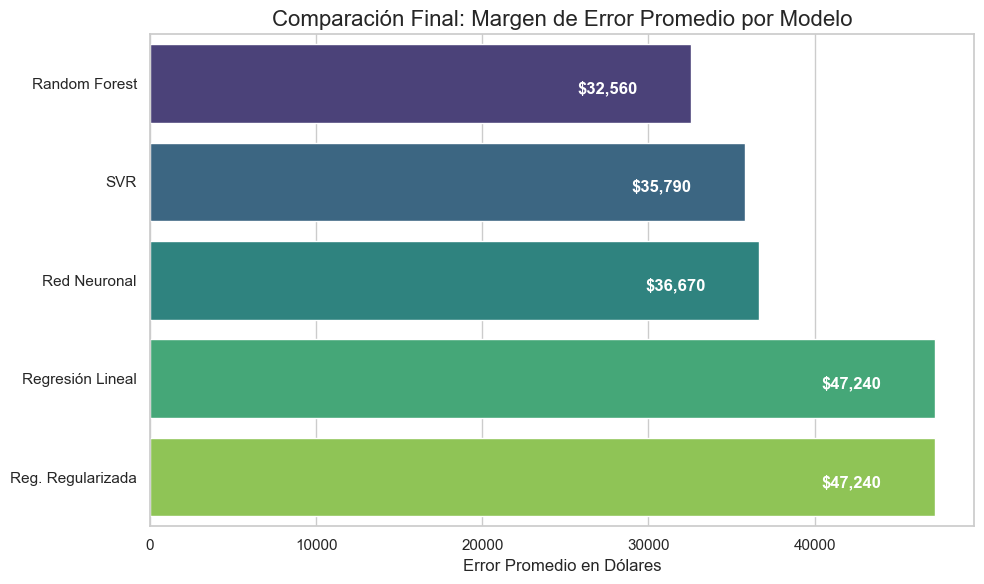


TABLA RESUMEN DE MODELOS


,R2_Score,Error en Dólares (MAE)
Modelo,,
Random Forest,0.7825,32560
SVR,0.7511,35790
Red Neuronal,0.7594,36670
Regresión Lineal,0.6352,47240
Reg. Regularizada,0.6352,47240


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

resultados = {
    'Modelo': ['Regresión Lineal', 'Reg. Regularizada', 'Random Forest', 'SVR', 'Red Neuronal'],
    'R2_Score': [0.6352, 0.6352, 0.7825, 0.7511, 0.7594],
    'Error en Dólares (MAE)': [47240, 47240, 32560, 35790, 36670]
}

df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values(by='Error en Dólares (MAE)')

plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

barplot = sns.barplot(x='Error en Dólares (MAE)', y='Modelo', data=df_resultados, palette='viridis')

for p in barplot.patches:
    width = p.get_width()
    plt.text(width - 5000, p.get_y() + p.get_height()/2. + 0.1,
             f'${int(width):,}', ha="center", color='white', weight='bold')

plt.title('Comparación Final: Margen de Error Promedio por Modelo', fontsize=16)
plt.xlabel('Error Promedio en Dólares', fontsize=12)
plt.ylabel('')
plt.tight_layout()
plt.show()

print("\nTABLA RESUMEN DE MODELOS")
display(df_resultados.set_index('Modelo'))

# Resumen de Resultados — Proyecto 1: Regresión

**Dataset:** California Housing (scikit-learn)  
**Variable objetivo:** `MedHouseVal` — Valor medio de vivienda (en cientos de miles de USD)  
**Integrantes:** Christopher Andres Obando Rivera · Mateo Murcia Valles

---

## Comparación de modelos

| Modelo | R² Score | MAE (USD) | Notas |
|---|---|---|---|
| Regresión Lineal | 0.6352 | $47,240 | Línea base |
| Reg. Regularizada (Ridge / Lasso / ElasticNet) | 0.6352 | $47,240 | Sin mejora sobre lineal — datos bien escalados |
| **Random Forest** | **0.7825** | **$32,560** |  **Mejor modelo** |
| SVR (kernel RBF) | 0.7511 | $35,790 | Buen desempeño, costoso computacionalmente |
| Red Neuronal (MLP) | 0.7594 | $36,670 | Competitivo, sensible a hiperparámetros |

---

## Mejores hiperparámetros encontrados

| Modelo | Parámetros óptimos (GridSearchCV) |
|---|---|
| Ridge | `alpha = 0.01` |
| Lasso | `alpha = 0.0001` |
| ElasticNet | `alpha = 0.0001`, `l1_ratio = 0.2` |
| Random Forest | `n_estimators = 100`, `max_depth = None`, `min_samples_split = 2` |
| SVR | `C = 10`, `epsilon = 0.2`, `kernel = 'rbf'` |
| Red Neuronal | `hidden_layer_sizes = (50,)`, `learning_rate_init = 0.01` |

---

## Conclusiones

- **La regularización no aportó mejora** sobre la regresión lineal. Esto sugiere que las variables predictoras ya estaban bien escaladas y que el modelo lineal no sufría de overfitting severo.
- **Random Forest fue el modelo ganador**, con el R² más alto (0.7825) y el menor error absoluto ($32,560). Su capacidad para capturar relaciones no lineales entre variables como `MedInc` y la ubicación geográfica (`Latitude`, `Longitude`) explica su superioridad.
- **SVR y la Red Neuronal** mostraron resultados competitivos, pero requieren mayor costo computacional y ajuste de hiperparámetros más cuidadoso.
- El **R² máximo alcanzado fue ~0.78**, lo que indica que aún hay variabilidad en el precio de las viviendas no explicada por las variables disponibles (factores como calidad de la construcción, acceso a servicios, etc., no están en el dataset).